In [1]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install scikit-learn scipy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
print(f"\nPandas version: {pd.__version__}")


Pandas version: 3.0.1


In [5]:
%pip install fastparquet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os 
from pathlib import Path

folder_path = Path(r"C:\Users\prana\Downloads\healthtables_export")
dataframes = {}
for file in folder_path.iterdir():
    dataframes[file.stem] = pd.read_parquet(file, engine='fastparquet')
    print(f"Loaded {file.stem} with shape {dataframes[file.stem].shape}")

Loaded hcpc_dict with shape (9006, 2)
Loaded medicaid_provider_spending with shape (227083361, 10)
Loaded npi_dict with shape (9368082, 8)
Loaded npi_endpoints with shape (593297, 19)
Loaded npi_othernames with shape (709422, 3)
Loaded npi_practice_locations with shape (1146558, 10)


In [3]:
df_medicaid_provider_spending = dataframes['medicaid_provider_spending']
df_medicaid_provider_spending.head()

,BILLING_PROVIDER_NPI_NUM,SERVICING_PROVIDER_NPI_NUM,HCPCS_CODE,CLAIM_FROM_MONTH,TOTAL_UNIQUE_BENEFICIARIES,TOTAL_CLAIMS,TOTAL_PAID,claim_year,claim_month,claim_yyyymm
0,1265668784,1487712865,Z6500,2018-05,78,78,9608.82,2018,5,201805
1,1285921064,1780200444,90837,2023-08,28,101,9608.82,2023,8,202308
2,1093761694,1437350774,T1015,2020-03,43,50,9608.82,2020,3,202003
3,1689626178,1689626178,99199,2024-04,449,1301,9608.82,2024,4,202404
4,1114239068,1114239068,93005,2018-07,354,403,9608.82,2018,7,201807


In [4]:
top_HCPCS_codes = df_medicaid_provider_spending['HCPCS_CODE'].value_counts().nlargest(10).index.tolist()
print(top_HCPCS_codes)

['99213', '99214', '99284', '99283', '99285', '36415', 'T1015', 'D0120', '85025', '90837']


In [5]:
npi_locations = dataframes['npi_practice_locations']
npi_locations

,NPI,Provider Secondary Practice Location Address- Address Line 1,Provider Secondary Practice Location Address- Address Line 2,Provider Secondary Practice Location Address - City Name,Provider Secondary Practice Location Address - State Name,Provider Secondary Practice Location Address - Postal Code,Provider Secondary Practice Location Address - Country Code (If outside U.S.),Provider Secondary Practice Location Address - Telephone Number,Provider Secondary Practice Location Address - Telephone Extension,Provider Practice Location Address - Fax Number
0,1467964916,4620 Cedar Ave Ste 122,,Wilmington,NC,284034423,US,9106161077,,9109209878
1,1467964932,N2615 Valley View Rd,,Norway,MI,498702271,US,9065631206,,
2,1467964932,333 S Stephenson Ave Apt 203D,,Iron Mountain,MI,498012942,US,9065631206,,
3,1467965343,311 Martin Luther King Dr E,,Cincinnati,OH,452192581,US,5133320350,,
4,1467965533,5190 Atlantic Ave,,Long Beach,CA,908056510,US,5624284111,,
...,...,...,...,...,...,...,...,...,...,...
1146553,1992998710,1905 SE 192nd Ave Ste 205,,Camas,WA,986077415,US,3602105440,,3602107731
1146554,1992998710,6542 SE Lake Rd Ste 105,,Milwaukie,OR,972222245,US,5034964550,,5034964551
1146555,1992998736,2658 Maguire Road,,Ocoee,FL,34761,US,4075819065,,3213485827
1146556,1992998876,810 W. Anthony Dr,,Urbana,IL,618027431,US,2173262911,,2173448047


In [6]:
NPI_filtered_MA = npi_locations[npi_locations['Provider Secondary Practice Location Address - State Name'] == 'MA']['NPI']
NPI_filtered_MA.value_counts()

NPI
1598257396    16
1689316283    16
1023175072    14
1508020199    13
1699752931    13
              ..
1992968200     1
1992970438     1
1992978910     1
1992995195     1
1992996177     1
Name: count, Length: 22574, dtype: int64

In [27]:
NPI_filtered_CA = npi_locations[npi_locations['Provider Secondary Practice Location Address - State Name'] == 'CA']['NPI']
NPI_filtered_CA

4          1467965533
19         1467966424
20         1467966424
21         1467966424
24         1467966598
              ...    
1146534    1992997001
1146535    1992997001
1146540    1992997217
1146549    1992998496
1146557    1992999569
Name: NPI, Length: 117601, dtype: uint64

In [28]:
medicaid_provider_spending_CA = df_medicaid_provider_spending[df_medicaid_provider_spending['SERVICING_PROVIDER_NPI_NUM'].isin(NPI_filtered_CA)]

In [7]:
medicaid_provider_spending_MA = df_medicaid_provider_spending[df_medicaid_provider_spending['SERVICING_PROVIDER_NPI_NUM'].isin(NPI_filtered_MA)]

In [9]:
hcpcs_data_dict = {}
for code in top_HCPCS_codes:
    condition = (medicaid_provider_spending_MA['HCPCS_CODE'] == code) & (medicaid_provider_spending_MA['TOTAL_PAID']  > 10000)
    subset_df = medicaid_provider_spending_MA[condition]

    if len(subset_df)>0:
        hcpcs_data_dict[code] = subset_df[['TOTAL_PAID', 'TOTAL_CLAIMS']]
    else:
        print('nga')
        

In [11]:
print(hcpcs_data_dict['99213'])

           TOTAL_PAID  TOTAL_CLAIMS
7957515     219496.28          1647
8849555     195244.43          1170
8850532     195011.14          1304
9036889     193626.48          1262
9042331     192397.55          1263
...               ...           ...
211117725    10058.77           764
211120831    10056.08            47
211313087    10045.72            27
211320235    10039.88           156
211651628    10015.38            53

[760 rows x 2 columns]


In [16]:
for code in top_HCPCS_codes:
    
    print(hcpcs_data_dict['code'])

KeyError: 'code'

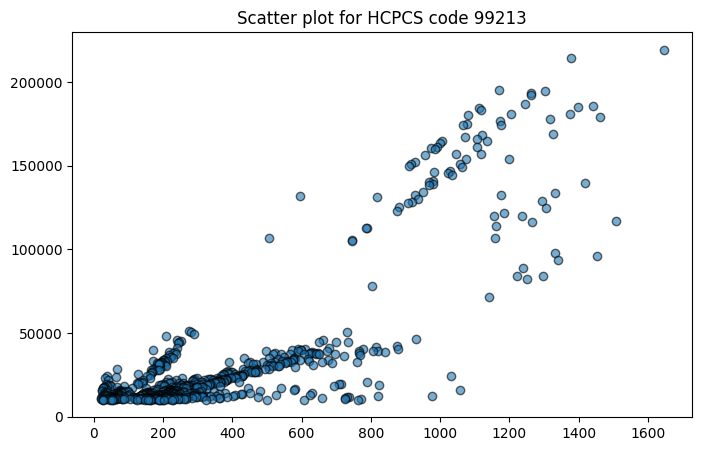

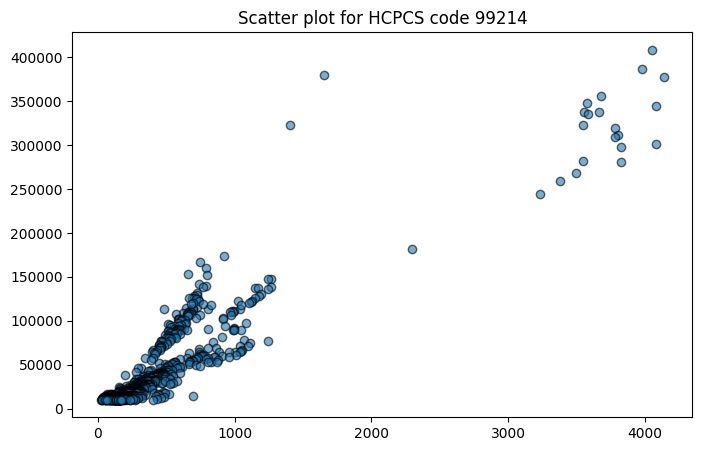

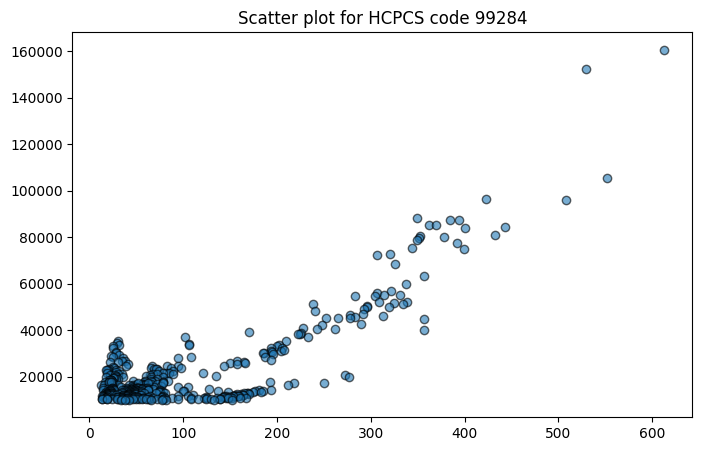

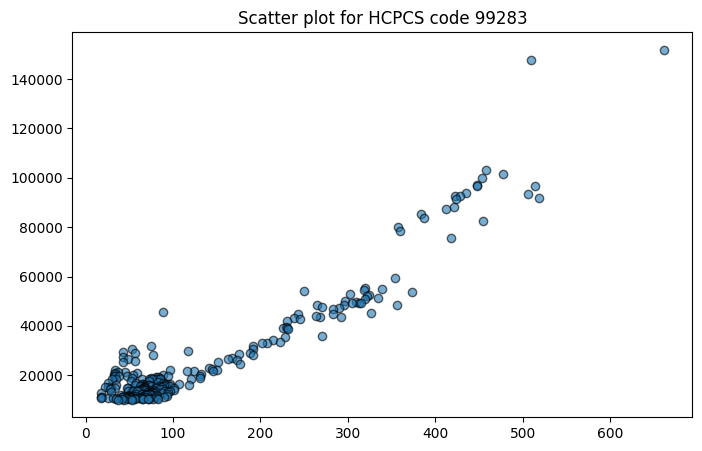

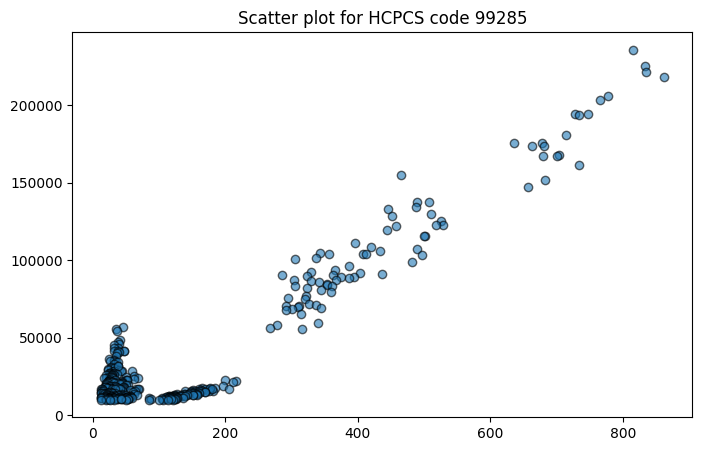

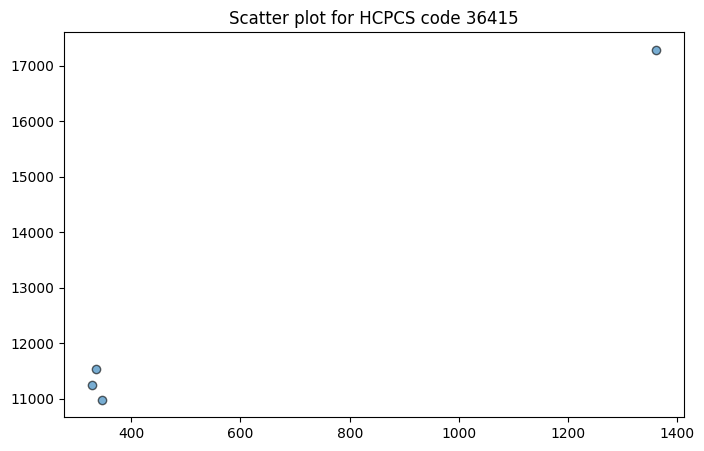

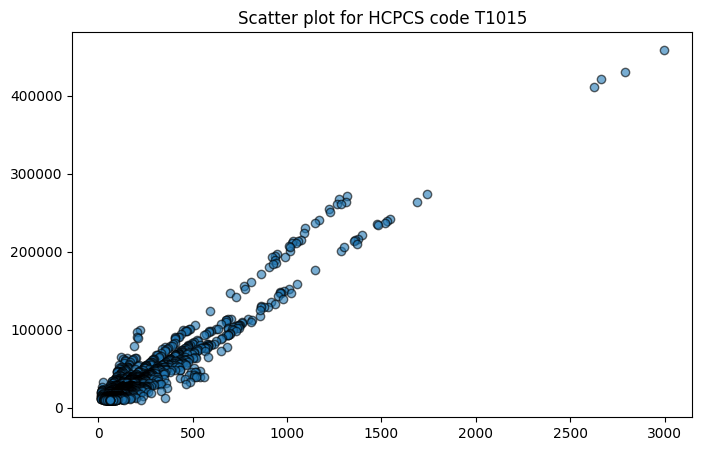

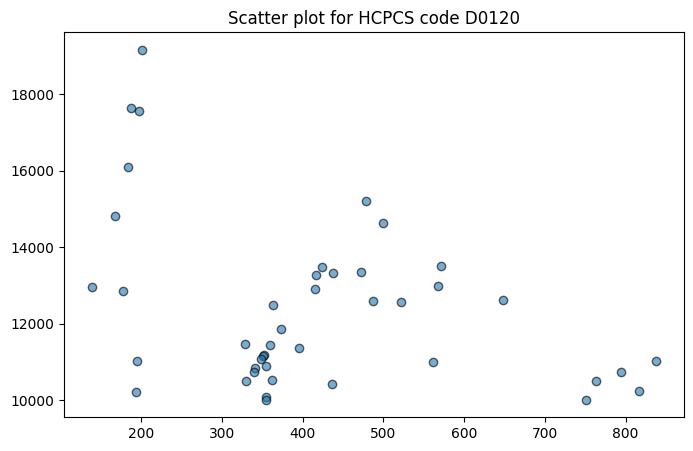

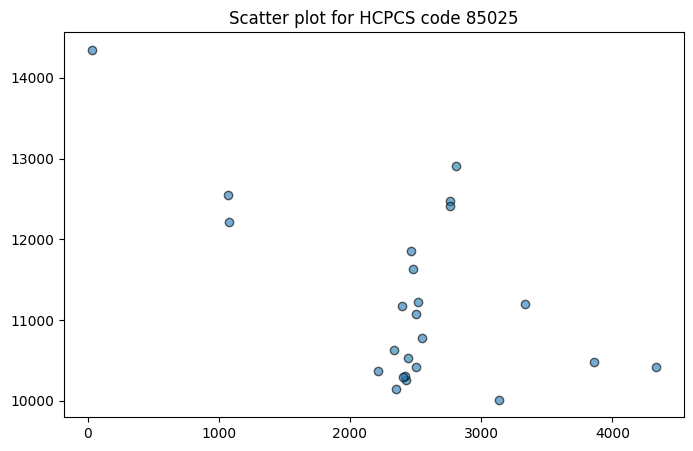

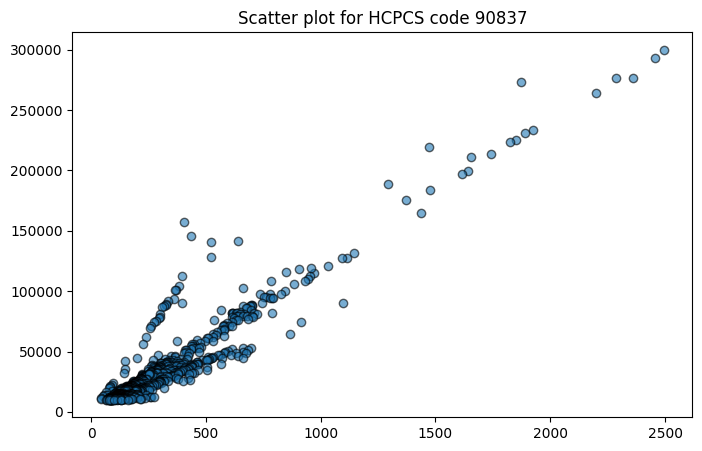

In [23]:
import matplotlib.pyplot as plt

for code, data in hcpcs_data_dict.items():
    plt.figure(figsize=(8,5))
    plt.scatter(data['TOTAL_CLAIMS'], data['TOTAL_PAID'], alpha = .6, edgecolors='k')
    plt.title(f'Scatter plot for HCPCS code {code}')

In [ ]:
medicaid_provider_spending_MA_99214 = medicaid_provider_spending_MA[medicaid_provider_spending_MA['HCPCS_CODE'] == '99214']
medicaid_provider_spending_MA_99214.head()

,BILLING_PROVIDER_NPI_NUM,SERVICING_PROVIDER_NPI_NUM,HCPCS_CODE,CLAIM_FROM_MONTH,TOTAL_UNIQUE_BENEFICIARIES,TOTAL_CLAIMS,TOTAL_PAID,claim_year,claim_month,claim_yyyymm
84,1275067118,1891903712,99214,2022-08,145,156,9608.76,2022,8,202208
1140,1841514122,1255660684,99214,2022-12,119,140,9607.85,2022,12,202212
10433,1013997329,1548592165,99214,2023-06,23,25,619.99,2023,6,202306
10520,1629398219,1417242074,99214,2022-11,12,12,619.99,2022,11,202211
15784,1538145131,1063706331,99214,2023-01,14,16,619.91,2023,1,202301


In [49]:
medicaid_provider_spending_CA_hospice= medicaid_provider_spending_CA[medicaid_provider_spending_CA['HCPCS_CODE'] == 'Q5005']
medicaid_provider_spending_CA_hospice

,BILLING_PROVIDER_NPI_NUM,SERVICING_PROVIDER_NPI_NUM,HCPCS_CODE,CLAIM_FROM_MONTH,TOTAL_UNIQUE_BENEFICIARIES,TOTAL_CLAIMS,TOTAL_PAID,claim_year,claim_month,claim_yyyymm


In [ ]:
hospice_codes = ['Q5001', 'Q5002','Q5003', 'Q5004', 'G0181', ]

In [ ]:
dataframes_to_combine = [ medicaid_provider_spending_CA[medicaid_provider_spending_CA['HCPCS_CODE'] == 'Q5001'],
                        medicaid_provider_spending_CA[medicaid_provider_spending_CA['HCPCS_CODE'] == 'Q5002'],
                        medicaid_provider_spending_CA[medicaid_provider_spending_CA['HCPCS_CODE'] == 'Q5003'],
                        medicaid_provider_spending_CA[medicaid_provider_spending_CA['HCPCS_CODE'] == 'Q5004']
                        medicaid_provider_spending_CA[medicaid_provider_spending_CA['HCPCS_CODE'] == 'G0180']
                        medicaid_provider_spending_CA[medicaid_provider_spending_CA['HCPCS_CODE'] == 'G0181']
                        medicaid_provider_spending_CA[medicaid_provider_spending_CA['HCPCS_CODE'] == 'T2046']
                        medicaid_provider_spending_CA[medicaid_provider_spending_CA['HCPCS_CODE'] == 'E0181']
                        medicaid_provider_spending_CA[medicaid_provider_spending_CA['HCPCS_CODE'] == 'A4604']
                        medicaid_provider_spending_CA[medicaid_provider_spending_CA['HCPCS_CODE'] == 'G0333']
                        medicaid_provider_spending_CA[medicaid_provider_spending_CA['HCPCS_CODE'] == 'S9122']
                        medicaid_provider_spending_CA[medicaid_provider_spending_CA['HCPCS_CODE'] == '99350']]

hospice_data = pd.concat(dataframes_to_combine, ignore_index=True)
hospice_data

,BILLING_PROVIDER_NPI_NUM,SERVICING_PROVIDER_NPI_NUM,HCPCS_CODE,CLAIM_FROM_MONTH,TOTAL_UNIQUE_BENEFICIARIES,TOTAL_CLAIMS,TOTAL_PAID,claim_year,claim_month,claim_yyyymm
0,1528615465,1528615465,Q5001,2024-06,42,43,0.0,2024,6,202406
1,1942860648,1942860648,Q5001,2024-02,13,13,0.0,2024,2,202402
2,1710173166,1710173166,Q5001,2024-06,16,16,0.0,2024,6,202406
3,1376583617,1376583617,Q5001,2020-07,18,18,0.0,2020,7,202007
4,1528153244,1528153244,Q5001,2024-08,13,15,0.0,2024,8,202408
...,...,...,...,...,...,...,...,...,...,...
314,1245825975,1134190713,Q5004,2022-07,14,122,0.0,2022,7,202207
315,1245825975,1134190713,Q5004,2022-08,18,114,0.0,2022,8,202208
316,1245825975,1134190713,Q5004,2022-12,13,18,0.0,2022,12,202212
317,1245825975,1134190713,Q5004,2022-10,13,20,0.0,2022,10,202210


In [53]:
hospice_data.to_csv(r'C:\Users\prana\Downloads\hospice_data.csv',index=False)

Text(0.5, 1.0, 'Total Claims vs Total Paid for Medicaid Providers in MA for HCPCS Code 99214')

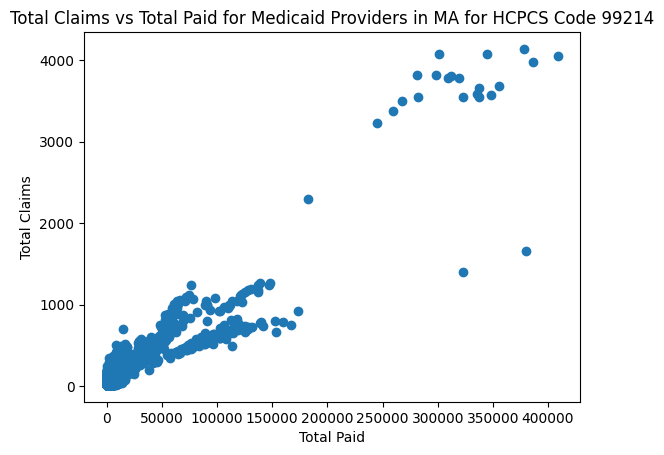

In [20]:
import matplotlib.pyplot as plt
plt.scatter(medicaid_provider_spending_MA_99214['TOTAL_PAID'],medicaid_provider_spending_MA_99214['TOTAL_CLAIMS'])
plt.xlabel('Total Paid')
plt.ylabel('Total Claims')
plt.title('Total Claims vs Total Paid for Medicaid Providers in MA for HCPCS Code 99214')

In [ ]:
pd.DataFrame.to_csv(medicaid_provider_spending_MA_99214, r"C:\Users\prana\Downloads\medicaid_provider_spending_MA_99214.csv", index=False)